In [1]:
import numpy as np 
import pandas as pd 
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D


In [3]:
data = pd.read_csv(r'C:\Users\mahdi\Desktop\Github\Cancer_Classification_Model\cleaned_data.csv')
data.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,1,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


In [4]:
data.shape

(569, 31)

In [8]:
x = data.drop(['diagnosis'], axis=1)
y = data['diagnosis']

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=11111)

In [5]:
model = Sequential()
model.add(Dense(16,input_dim=30,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

C:\Users\mahdi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 513 (2.00 KB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
from keras.optimizers import SGD
model.compile(SGD(learning_rate=0.003), "binary_crossentropy", metrics=["accuracy"])
run_hist_1 = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=200)

Epoch 1/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.3797 - loss: 0.8832 - val_accuracy: 0.4266 - val_loss: 0.8492
Epoch 2/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4867 - loss: 0.8037 - val_accuracy: 0.4755 - val_loss: 0.7831
Epoch 3/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4740 - loss: 0.8053 - val_accuracy: 0.5524 - val_loss: 0.7269
Epoch 4/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5178 - loss: 0.7205 - val_accuracy: 0.6364 - val_loss: 0.6779
Epoch 5/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5854 - loss: 0.6770 - val_accuracy: 0.6783 - val_loss: 0.6344
Epoch 6/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6522 - loss: 0.6276 - val_accuracy: 0.7063 - val_loss: 0.5963
Epoch 7/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6944 - loss: 0.5796 - val_accuracy: 0.7483 - val_loss: 0.5614
Epoch 8/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7495 - loss: 0.5399 - val_accuracy: 0.7972 - 

In [12]:
y_pred_prob_nn_1 = model.predict(X_test)
y_pred_class_nn_1 = (y_pred_prob_nn_1 > 0.5).astype(int)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


In [13]:
y_pred_class_nn_1[:10]

array([[0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0]])

In [15]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score , roc_auc_score
print('accuracy is {:.3f}'.format(accuracy_score(y_test,y_pred_class_nn_1)))
print('roc-auc is {:.3f}'.format(roc_auc_score(y_test,y_pred_prob_nn_1)))



accuracy is 0.965
roc-auc is 0.996


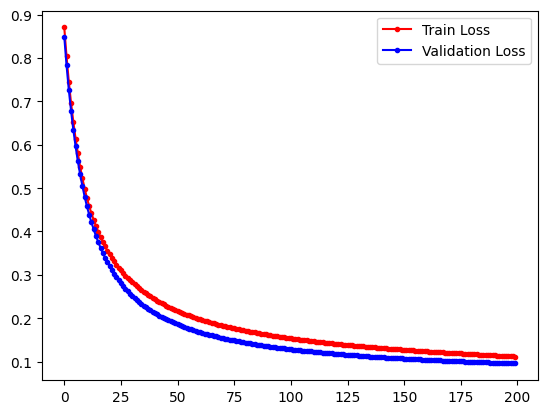

In [17]:
import matplotlib.pyplot as plt 
fig, ax = plt.subplots()
ax.plot(run_hist_1.history["loss"],'r', marker='.', label="Train Loss")
ax.plot(run_hist_1.history["val_loss"],'b', marker='.', label="Validation Loss")
ax.legend()

In [18]:
run_hist_1b = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=1000)

Epoch 1/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9846 - loss: 0.0980 - val_accuracy: 0.9650 - val_loss: 0.0955
Epoch 2/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9760 - loss: 0.1083 - val_accuracy: 0.9650 - val_loss: 0.0954
Epoch 3/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9682 - loss: 0.1101 - val_accuracy: 0.9650 - val_loss: 0.0952
Epoch 4/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9714 - loss: 0.1099 - val_accuracy: 0.9650 - val_loss: 0.0950
Epoch 5/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9790 - loss: 0.1034 - val_accuracy: 0.9650 - val_loss: 0.0948
Epoch 6/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9622 - loss: 0.1205 - val_accuracy: 0.9650 - val_loss: 0.0946
Epoch 7/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9683 - loss: 0.1286 - val_accuracy: 0.9650 - val_loss: 0.0944
Epoch 8/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9671 - loss: 0.1205 - val_accuracy: 0

In [22]:
y_pred_prob_nn_1_b = model.predict(X_test)
y_pred_class_nn_1_b = (y_pred_prob_nn_1_b > 0.5).astype(int)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


In [24]:
print('accuracy is {:.3f}'.format(accuracy_score(y_test,y_pred_class_nn_1_b)))
print('roc-auc is {:.3f}'.format(roc_auc_score(y_test,y_pred_prob_nn_1_b)))


accuracy is 0.972
roc-auc is 0.995


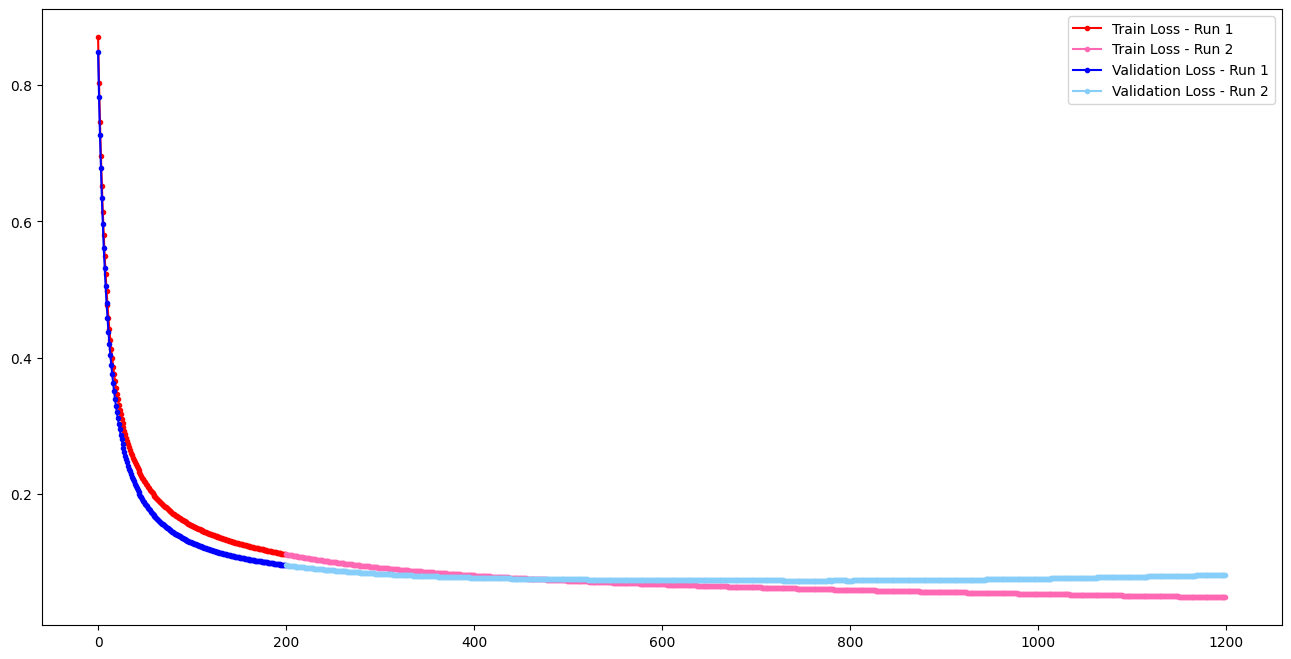

In [25]:
n = len(run_hist_1.history["loss"])
m = len(run_hist_1b.history['loss'])
fig, ax = plt.subplots(figsize=(16, 8))

ax.plot(range(n), run_hist_1.history["loss"],'r', marker='.', label="Train Loss - Run 1")
ax.plot(range(n, n+m), run_hist_1b.history["loss"], 'hotpink', marker='.', label="Train Loss - Run 2")

ax.plot(range(n), run_hist_1.history["val_loss"],'b', marker='.', label="Validation Loss - Run 1")
ax.plot(range(n, n+m), run_hist_1b.history["val_loss"], 'LightSkyBlue', marker='.',  label="Validation Loss - Run 2")

ax.legend()

In [30]:
model_2 = Sequential()
model_2.add(Dense(16,input_dim=30,activation='relu'))
model_2.add(Dense(16,activation='relu'))
model_2.add(Dense(1,activation='sigmoid'))
model_2.compile(SGD(learning_rate=0.003), "binary_crossentropy", metrics=["accuracy"])
run_hist_2 = model_2.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=1500)


Epoch 1/1500


C:\Users\mahdi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.3999 - loss: 0.8641 - val_accuracy: 0.3007 - val_loss: 0.8887
Epoch 2/1500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3910 - loss: 0.8261 - val_accuracy: 0.3007 - val_loss: 0.8386
Epoch 3/1500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4163 - loss: 0.7879 - val_accuracy: 0.3007 - val_loss: 0.7931
Epoch 4/1500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4039 - loss: 0.7449 - val_accuracy: 0.3217 - val_loss: 0.7540
Epoch 5/1500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4049 - loss: 0.7352 - val_accuracy: 0.3497 - val_loss: 0.7193
Epoch 6/1500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4473 - loss: 0.6904 - val_accuracy: 0.3776 - val_loss: 0.6885
Epoch 7/1500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4430 - loss: 0.6883 - val_accuracy: 0.4126 - val_loss: 0.6606
Epoch 8/1500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5082 - loss: 0.6627 - val_accuracy: 0.5175 - val_l

In [32]:
y_pred_prob_nn_2 = model_2.predict(X_test)
y_pred_class_nn_2 = (y_pred_prob_nn_2 > 0.5).astype(int)
print('accuracy is {:.3f}'.format(accuracy_score(y_test,y_pred_class_nn_2)))
print('roc-auc is {:.3f}'.format(roc_auc_score(y_test,y_pred_prob_nn_2)))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
accuracy is 0.979
roc-auc is 0.997


In [39]:
model_2 = Sequential()
model_2.add(Dense(32,input_dim=30,activation='leaky_relu'))
model_2.add(Dense(32,activation='leaky_relu'))
model_2.add(Dense(32,activation='leaky_relu'))
model_2.add(Dense(1,activation='sigmoid'))
model_2.compile(SGD(learning_rate=0.005), "binary_crossentropy", metrics=["accuracy"])
run_hist_2 = model_2.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=1500)

Epoch 1/1500


C:\Users\mahdi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.4684 - loss: 0.7567 - val_accuracy: 0.6294 - val_loss: 0.6404
Epoch 2/1500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6693 - loss: 0.6159 - val_accuracy: 0.7832 - val_loss: 0.5553
Epoch 3/1500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7661 - loss: 0.5535 - val_accuracy: 0.8671 - val_loss: 0.4905
Epoch 4/1500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8647 - loss: 0.4994 - val_accuracy: 0.9021 - val_loss: 0.4390
Epoch 5/1500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9026 - loss: 0.4554 - val_accuracy: 0.9231 - val_loss: 0.3973
Epoch 6/1500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9076 - loss: 0.4036 - val_accuracy: 0.9231 - val_loss: 0.3621
Epoch 7/1500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9025 - loss: 0.3901 - val_accuracy: 0.9371 - val_loss: 0.3329
Epoch 8/1500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9263 - loss: 0.3659 - val_accuracy: 0.9441 - val_l

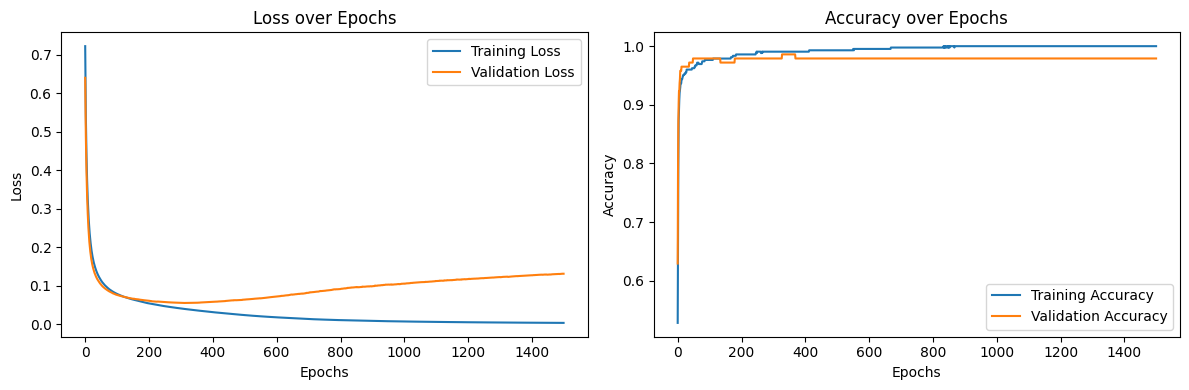

In [41]:
import matplotlib.pyplot as plt

# Extract metrics
loss = run_hist_2.history['loss']
val_loss = run_hist_2.history['val_loss']
acc = run_hist_2.history['accuracy']
val_acc = run_hist_2.history['val_accuracy']

# Plot Loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.tight_layout()
plt.show()
